# Customer Review Sentiment Analytics
### Big Data Analytics using Python and Machine Learning

**Objective:** classify Amazon product reviews as **positive, negative or neutral**, and extract business insights from ~200,000 customer reviews.

**Tools:** Python · Pandas · NumPy · Scikit-learn · Jupyter Notebook · Streamlit (dashboard in `app.py`)

| Step | What we do |
|---|---|
| 1 | Load & profile the data (volume, quality, class balance) |
| 2 | Exploratory data analysis (EDA) |
| 3 | Text pre-processing (NLP) |
| 4 | Feature engineering with TF-IDF (+ ablation study) |
| 5 | Train & compare 6 machine-learning models |
| 6 | Hyper-parameter tuning with cross-validation |
| 7 | Final evaluation on an untouched test set |
| 8 | Error analysis & model interpretability |
| 9 | **Big-data angle:** scalability study + out-of-core streaming training |
| 10 | Business insights, conclusions, future work |

**Labelling rule:** 1-2 stars = *negative*, 3 stars = *neutral*, 4-5 stars = *positive*.

## 0. Setup

In [1]:
import os, sys, time, warnings
warnings.filterwarnings("ignore")
PROJECT = os.path.abspath("..")
sys.path.insert(0, PROJECT)                         # make `src` importable from notebooks/
os.environ["PYTHONPATH"] = PROJECT                  # ...and in joblib worker processes (GridSearchCV n_jobs=-1)

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from collections import Counter
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, roc_auc_score)
from sklearn.preprocessing import label_binarize

from src.preprocess import load_reviews, clean_text, STOP_WORDS, KEEP_WORDS, LABELS, LABEL_COLORS, RAW_PATH, ROOT
CLOUD_EXTRA = {"s", "t", "d", "m", "ll", "ve", "re", "did", "does", "got", "just", "one", "will", "would", "also", "really", "product", "item"}  # word-cloud visuals only
from src.modeling import make_vectorizer, scores, SEED

sns.set_theme(style="whitegrid", context="notebook")
OUT = ROOT / "outputs"; FIG = OUT / "figures"; FIG.mkdir(parents=True, exist_ok=True)
def savefig(name):
    plt.savefig(FIG / name, dpi=150, bbox_inches="tight")

## 1. Data loading & profiling
The dataset is the **Amazon Reviews (English)** corpus from Hugging Face (`SetFit/amazon_reviews_multi_en`), ~200k reviews rated 1-5 stars.
It is "big" for text analytics: 200k documents → a sparse matrix with hundreds of thousands of features, which is why we use
**sparse matrices, linear models and an out-of-core streaming approach** later in the notebook.

In [2]:
print(f"Raw file size: {RAW_PATH.stat().st_size / 1e6:.1f} MB")
raw = pd.read_json(RAW_PATH, lines=True)
print("Raw rows:", len(raw))
df = load_reviews()
print("After removing empty & duplicate reviews:", len(df), f"(dropped {len(raw) - len(df):,})")
print(f"In-memory size: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head()

Raw file size: 47.4 MB


Raw rows: 200000


After removing empty & duplicate reviews: 199426 (dropped 574)
In-memory size: 47.5 MB


,id,review,stars,sentiment,word_count
0,en_0964290,Arrived broken. Manufacturer defect. Two of th...,1,negative,112
1,en_0690095,the cabinet dot were all detached from backing...,1,negative,10
2,en_0311558,I received my first order of this product and ...,1,negative,40
3,en_0044972,This product is a piece of shit. Do not buy. D...,1,negative,29
4,en_0784379,went through 3 in one day doesn't fit correct ...,1,negative,16


In [3]:
display(df.dtypes.to_frame("dtype"))
print("Missing values per column:"); print(df.isna().sum())
df.describe(include="all").T

,dtype
id,str
review,str
stars,int64
sentiment,str
word_count,int64


Missing values per column:
id            0
review        0
stars         0
sentiment     0
word_count    0
dtype: int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,199426,199426,en_0964290,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review,199426,199426,Arrived broken. Manufacturer defect. Two of th...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stars,199426.0,NaN,NaN,NaN,2.998997,1.413681,1.0,2.0,3.0,4.0,5.0
sentiment,199426,3,negative,79819,NaN,NaN,NaN,NaN,NaN,NaN,NaN
word_count,199426.0,NaN,NaN,NaN,34.19844,34.213189,1.0,13.0,24.0,44.0,769.0


## 2. Exploratory data analysis

### 2.1 Class balance

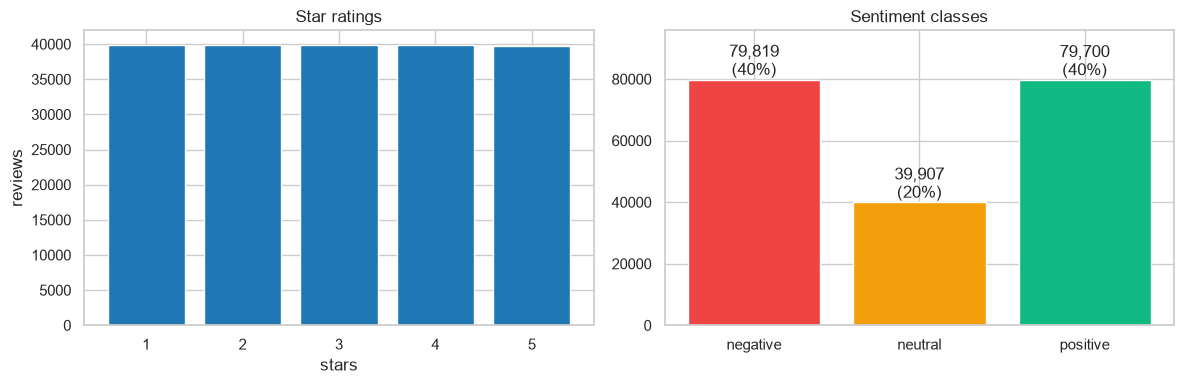

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
star_counts = df["stars"].value_counts().sort_index()
axes[0].bar(star_counts.index, star_counts.values, color="#1f77b4"); axes[0].set(title="Star ratings", xlabel="stars", ylabel="reviews")
sent_counts = df["sentiment"].value_counts().reindex(LABELS)
axes[1].bar(sent_counts.index, sent_counts.values, color=[LABEL_COLORS[l] for l in LABELS]); axes[1].set(title="Sentiment classes")
for i, v in enumerate(sent_counts.values): axes[1].text(i, v, f"{v:,}\n({v/len(df):.0%})", ha="center", va="bottom")
axes[1].set_ylim(0, sent_counts.max() * 1.2)
plt.tight_layout(); savefig("eda_class_distribution.png"); plt.show()

**Observation:** the classes are *moderately imbalanced* - neutral (3★) is only ~20 % of the data. Plain accuracy can hide poor neutral
performance, so we report **macro-F1** (every class counts equally) and use `class_weight="balanced"`.

### 2.2 Review length

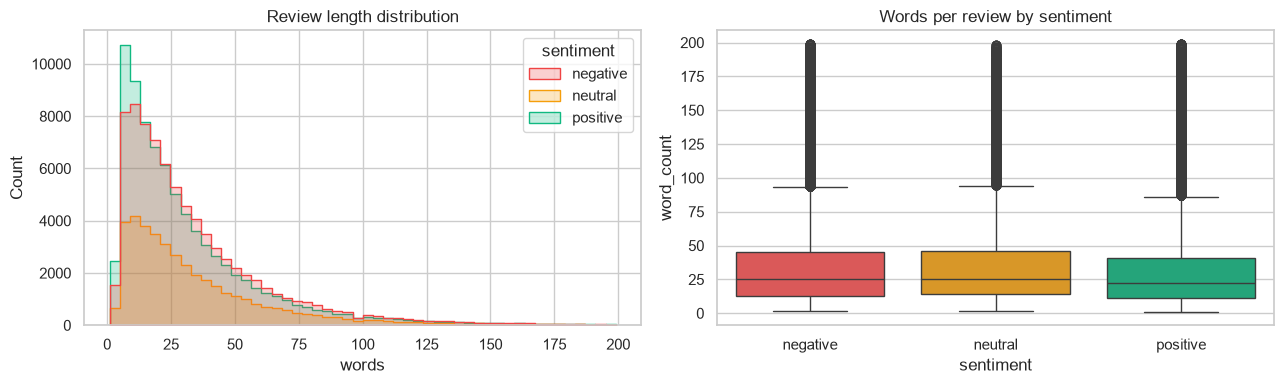

,mean,median,max
sentiment,,,
negative,35.0,25.0,644
neutral,36.4,26.0,713
positive,32.3,22.0,769


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=df[df.word_count < 200], x="word_count", hue="sentiment", hue_order=LABELS, palette=LABEL_COLORS,
             bins=50, element="step", ax=axes[0]); axes[0].set(title="Review length distribution", xlabel="words")
sns.boxplot(data=df[df.word_count < 200], x="sentiment", y="word_count", order=LABELS, palette=LABEL_COLORS, ax=axes[1])
axes[1].set(title="Words per review by sentiment")
plt.tight_layout(); savefig("eda_review_length.png"); plt.show()
df.groupby("sentiment")["word_count"].agg(["mean", "median", "max"]).round(1).reindex(LABELS)

**Observation:** review length is very similar across the three classes (mean ≈ 32-36 words; neutral and negative reviews are only slightly longer than positive ones). Length alone is therefore a weak signal - the *words* matter, which is why we use TF-IDF features.

### 2.3 Word clouds per sentiment

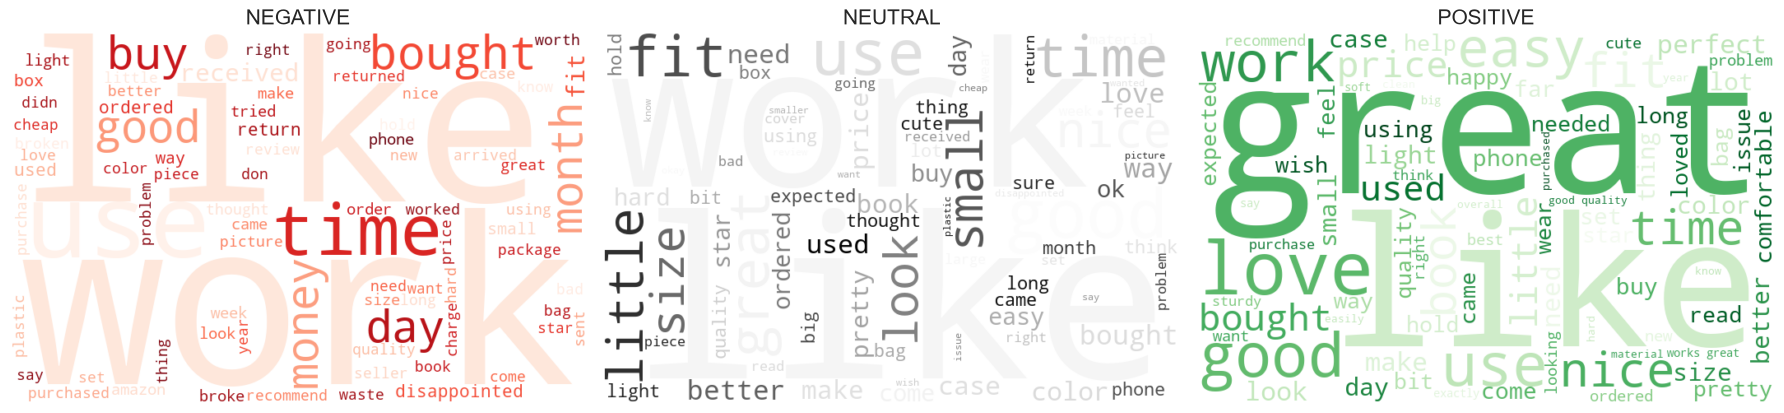

In [6]:
sample = df.sample(60_000, random_state=SEED)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, lab, cmap in zip(axes, LABELS, ["Reds", "Greys", "Greens"]):
    text = " ".join(sample.loc[sample.sentiment == lab, "review"].map(clean_text))
    wc = WordCloud(width=700, height=450, background_color="white", stopwords=set(STOP_WORDS) | KEEP_WORDS | CLOUD_EXTRA, colormap=cmap,
                   max_words=80, random_state=SEED).generate(text)
    ax.imshow(wc, interpolation="bilinear"); ax.axis("off"); ax.set_title(lab.upper(), fontsize=15)
plt.tight_layout(); savefig("eda_wordclouds.png"); plt.show()

### 2.4 Most frequent words and bigrams per class

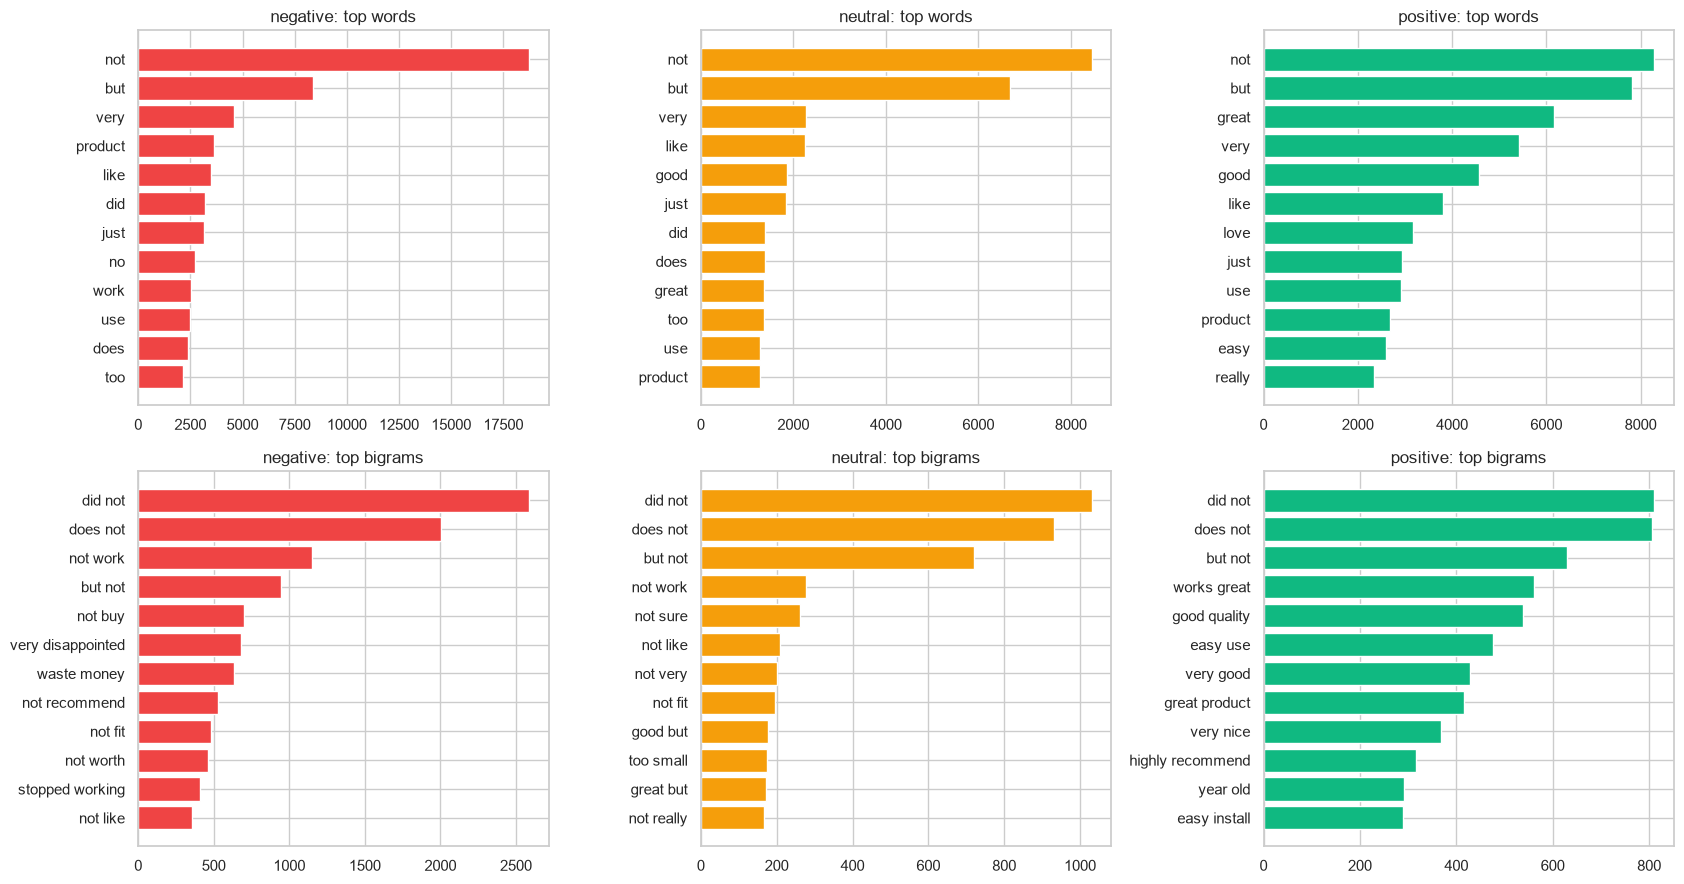

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for j, lab in enumerate(LABELS):
    texts = sample.loc[sample.sentiment == lab, "review"]
    for i, ng in enumerate([(1, 1), (2, 2)]):
        cv = CountVectorizer(preprocessor=clean_text, stop_words=STOP_WORDS, ngram_range=ng, max_features=2000)
        counts = np.asarray(cv.fit_transform(texts).sum(axis=0)).ravel()
        top = pd.Series(counts, index=cv.get_feature_names_out()).nlargest(12)[::-1]
        axes[i, j].barh(top.index, top.values, color=LABEL_COLORS[lab])
        axes[i, j].set_title(f"{lab}: top {'words' if i == 0 else 'bigrams'}")
plt.tight_layout(); savefig("eda_top_terms.png"); plt.show()

## 3. Text pre-processing
Steps: HTML/URL removal → lower-casing → contraction expansion (*don't → do not*) → remove digits/punctuation → remove stop-words.

> **Design decision:** standard stop-word lists contain *not, no, never, very, too*. Removing them would turn *"not good"* into *"good"*
> and destroy the sentiment. We **keep negations and intensifiers**.

In [8]:
examples = ["I DON'T like it!! <br> Can't recommend, 0/10. See http://spam.com",
            "Not bad at all, very happy with this purchase :)",
            "Won't work with my phone... Total waste of $$$"]
pd.DataFrame({"original": examples, "cleaned": [clean_text(e) for e in examples]})

,original,cleaned
0,"I DON'T like it!! <br> Can't recommend, 0/10. ...",i do not like it can not recommend see
1,"Not bad at all, very happy with this purchase :)",not bad at all very happy with this purchase
2,Won't work with my phone... Total waste of $$$,will not work with my phone total waste of


In [9]:
print(f"Stop-words removed: {len(STOP_WORDS)}")
print("Negations/intensifiers preserved:", [w for w in ["not", "no", "never", "very", "too", "nothing"] if w not in STOP_WORDS])

Stop-words removed: 297
Negations/intensifiers preserved: ['not', 'no', 'never', 'very', 'too', 'nothing']


## 4. Train / validation / test split
**70 % train · 10 % validation · 20 % test**, stratified so each split keeps the class ratio.
* *Train* - fit models. * *Validation* - compare models and tune hyper-parameters. * *Test* - touched **once** at the end, giving an unbiased estimate.

In [10]:
X_tmp, X_test, y_tmp, y_test = train_test_split(df["review"], df["sentiment"], test_size=0.20, stratify=df["sentiment"], random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.125, stratify=y_tmp, random_state=SEED)
pd.DataFrame({"reviews": [len(X_train), len(X_val), len(X_test)],
              **{l: [(s == l).mean() for s in (y_train, y_val, y_test)] for l in LABELS}},
             index=["train", "validation", "test"]).round(3)

,reviews,negative,neutral,positive
train,139597,0.4,0.2,0.4
validation,19943,0.4,0.2,0.4
test,39886,0.4,0.2,0.4


## 5. Feature engineering - TF-IDF
Machine-learning models need numbers, so each review becomes a **TF-IDF vector**: a word's weight rises with how often it appears in the
review (sub-linearly scaled) and falls with how many reviews contain it. **Bigrams** capture phrases such as *"not good"* or *"stopped working"*.

Because most words are absent from most reviews, the result is a **sparse matrix** (stored efficiently by SciPy) - essential at this scale.

In [11]:
t = time.time()
vec = make_vectorizer()
Xtr = vec.fit_transform(X_train); Xva = vec.transform(X_val)
print(f"TF-IDF matrix: {Xtr.shape[0]:,} reviews x {Xtr.shape[1]:,} features  ({time.time()-t:.0f}s)")
dense_gb = Xtr.shape[0] * Xtr.shape[1] * 4 / 1e9
print(f"Non-zero entries: {Xtr.nnz:,}  | sparsity: {1 - Xtr.nnz / np.prod(Xtr.shape):.4%}")
print(f"Sparse memory: {(Xtr.data.nbytes + Xtr.indices.nbytes + Xtr.indptr.nbytes)/1e6:.0f} MB   vs   dense would need {dense_gb:,.0f} GB")

TF-IDF matrix: 139,597 reviews x 132,563 features  (32s)
Non-zero entries: 3,173,158  | sparsity: 99.9829%
Sparse memory: 26 MB   vs   dense would need 74 GB


### 5.1 Ablation: which feature settings help?
Quick experiment (Logistic Regression, 60k-review subsample, scored on the validation set) to **justify** our vectorizer choices.

In [12]:
sub = X_train.sample(60_000, random_state=SEED); ysub = y_train.loc[sub.index]
configs = {
    "unigrams only":                dict(ngram_range=(1, 1)),
    "unigrams + bigrams (chosen)":  dict(ngram_range=(1, 2)),
    "uni+bi+trigrams":              dict(ngram_range=(1, 3)),
    "bigrams, NO negation kept":    dict(ngram_range=(1, 2), stop_words="english"),
    "bigrams, raw tf (no sublinear)": dict(ngram_range=(1, 2), sublinear_tf=False),
}
rows = []
for name, kw in configs.items():
    v = make_vectorizer(**kw); A = v.fit_transform(sub)
    m = LogisticRegression(C=2, class_weight="balanced", max_iter=300).fit(A, ysub)
    rows.append({"setting": name, "features": A.shape[1], **scores(y_val, m.predict(v.transform(X_val)))})
ablation = pd.DataFrame(rows).set_index("setting"); ablation.to_csv(OUT / "ablation.csv"); ablation.round(4)

,features,accuracy,macro_f1,weighted_f1
setting,,,,
unigrams only,12971,0.6634,0.6287,0.6745
unigrams + bigrams (chosen),58420,0.6898,0.6494,0.6967
uni+bi+trigrams,68327,0.6915,0.6512,0.6984
"bigrams, NO negation kept",53147,0.6634,0.6231,0.6701
"bigrams, raw tf (no sublinear)",58420,0.6893,0.6491,0.6964


**Takeaway:** bigrams help over unigrams, and discarding negation words (the standard `stop_words="english"` list) hurts - confirming the design decision in Section 3.

## 6. Model training & comparison (validation set)

In [13]:
models = {
    "Baseline (majority class)": DummyClassifier(strategy="most_frequent"),
    "Multinomial Naive Bayes":   MultinomialNB(alpha=0.3),
    "Complement Naive Bayes":    ComplementNB(alpha=0.3),
    "SGD (modified Huber)":      SGDClassifier(loss="modified_huber", alpha=2e-6, class_weight="balanced", max_iter=30, random_state=SEED),
    "Linear SVM":                LinearSVC(C=0.1, class_weight="balanced", random_state=SEED),
    "Logistic Regression":       LogisticRegression(C=2, class_weight="balanced", max_iter=300),
}
rows, fitted = [], {}
for name, m in models.items():
    t = time.time(); m.fit(Xtr, y_train); sec = time.time() - t
    fitted[name] = m
    rows.append({"model": name, **scores(y_val, m.predict(Xva)), "train_seconds": sec})
comparison = pd.DataFrame(rows).set_index("model").sort_values("macro_f1", ascending=False)
comparison.round(4)

,accuracy,macro_f1,weighted_f1,train_seconds
model,,,,
Logistic Regression,0.7029,0.6633,0.7097,21.1217
Linear SVM,0.7198,0.6588,0.7121,5.8970
Complement Naive Bayes,0.7018,0.6192,0.6815,1.3330
SGD (modified Huber),0.6700,0.6161,0.6692,3.7254
Multinomial Naive Bayes,0.7079,0.5968,0.6704,1.1130
Baseline (majority class),0.4002,0.1906,0.2288,0.2368


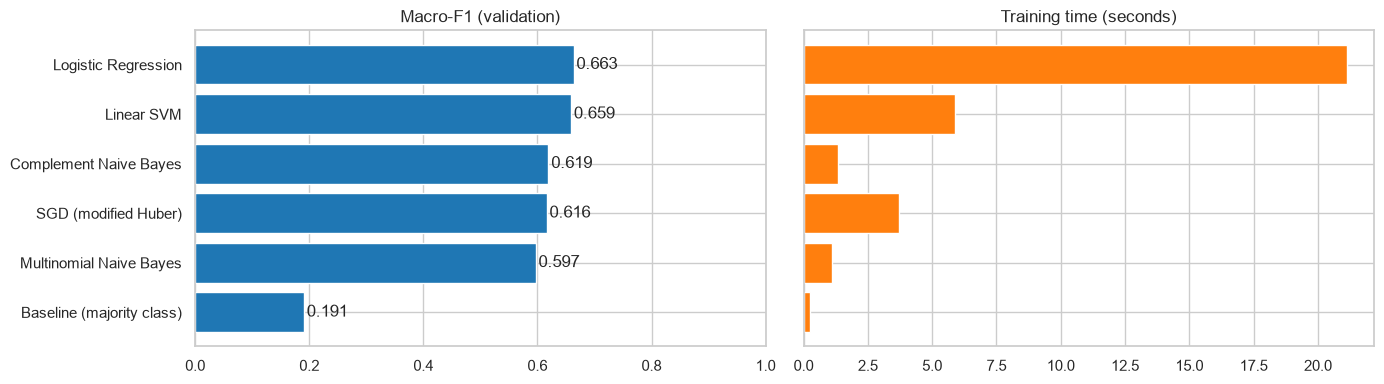

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
c = comparison.sort_values("macro_f1")
ax[0].barh(c.index, c["macro_f1"], color="#1f77b4"); ax[0].set(title="Macro-F1 (validation)", xlim=(0, 1))
for y, v in enumerate(c["macro_f1"]): ax[0].text(v + .005, y, f"{v:.3f}", va="center")
ax[1].barh(c.index, c["train_seconds"], color="#ff7f0e"); ax[1].set(title="Training time (seconds)"); ax[1].set_yticklabels([])
plt.tight_layout(); savefig("model_comparison_nb.png"); plt.show()

**Observations**
* Every real model beats the majority-class baseline by a wide margin.
* Linear models (Logistic Regression, SVM) dominate on high-dimensional sparse text; Naive Bayes is very fast but slightly less accurate.
* Linear models are also **scalable** - training cost grows roughly linearly with data, which matters for big data.

## 7. Hyper-parameter tuning with cross-validation
We tune the regularisation strength `C` **and** vectorizer settings with a full `Pipeline` inside 3-fold stratified CV on a 40k subsample
(the vectorizer is re-fit inside each fold → no information leaks from validation folds).

In [15]:
sub = X_train.sample(40_000, random_state=1); ysub = y_train.loc[sub.index]
pipe = Pipeline([("tfidf", make_vectorizer()), ("clf", LogisticRegression(class_weight="balanced", max_iter=300))])
grid = {"tfidf__ngram_range": [(1, 1), (1, 2)], "tfidf__min_df": [2, 5], "clf__C": [0.5, 1, 2, 5]}
gs = GridSearchCV(pipe, grid, scoring="f1_macro", cv=StratifiedKFold(3, shuffle=True, random_state=SEED), n_jobs=-1, verbose=0)
t = time.time(); gs.fit(sub, ysub)
print(f"Grid search finished in {time.time()-t:.0f}s | best CV macro-F1 = {gs.best_score_:.4f}")
print("Best params:", gs.best_params_)
pd.DataFrame(gs.cv_results_)[["param_tfidf__ngram_range", "param_tfidf__min_df", "param_clf__C", "mean_test_score", "std_test_score"]] \
  .sort_values("mean_test_score", ascending=False).head(8).round(4)

Grid search finished in 71s | best CV macro-F1 = 0.6523
Best params: {'clf__C': 0.5, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2)}


,param_tfidf__ngram_range,param_tfidf__min_df,param_clf__C,mean_test_score,std_test_score
3,"(1, 2)",5,0.5,0.6523,0.0023
5,"(1, 2)",2,1.0,0.6516,0.0041
1,"(1, 2)",2,0.5,0.6512,0.0025
7,"(1, 2)",5,1.0,0.6501,0.0028
9,"(1, 2)",2,2.0,0.6453,0.0023
11,"(1, 2)",5,2.0,0.6441,0.0010
2,"(1, 1)",5,0.5,0.6376,0.0012
0,"(1, 1)",2,0.5,0.6373,0.0015


In [16]:
# Fine-tune C on the full training set, scored on validation
tune = []
for name, Model in [("Logistic Regression", lambda C: LogisticRegression(C=C, class_weight="balanced", max_iter=300)),
                    ("Linear SVM", lambda C: LinearSVC(C=C, class_weight="balanced", random_state=SEED))]:
    for C in ([0.5, 1, 2, 5] if name.startswith("Log") else [0.03, 0.1, 0.3, 1]):
        m = Model(C).fit(Xtr, y_train); tune.append({"model": name, "C": C, **scores(y_val, m.predict(Xva))})
tune = pd.DataFrame(tune); display(tune.round(4))
best_C = tune[tune.model == "Logistic Regression"].sort_values("macro_f1").iloc[-1]["C"]
print("Selected: Logistic Regression with C =", best_C)

,model,C,accuracy,macro_f1,weighted_f1
0,Logistic Regression,0.50,0.7007,0.6666,0.7104
1,Logistic Regression,1.00,0.7034,0.6660,0.7112
2,Logistic Regression,2.00,0.7029,0.6633,0.7097
3,Logistic Regression,5.00,0.6979,0.6542,0.7028
4,Linear SVM,0.03,0.7140,0.6502,0.7044
5,Linear SVM,0.10,0.7198,0.6588,0.7121
6,Linear SVM,0.30,0.7150,0.6555,0.7090
7,Linear SVM,1.00,0.6980,0.6412,0.6946


Selected: Logistic Regression with C = 0.5


## 8. Final model - evaluation on the untouched test set
We refit on train+validation (80 %) and evaluate **once** on the 20 % test set.

In [17]:
X_fit, y_fit = pd.concat([X_train, X_val]), pd.concat([y_train, y_val])
vec = make_vectorizer(); Xfit = vec.fit_transform(X_fit); Xte = vec.transform(X_test)
clf = LogisticRegression(C=best_C, class_weight="balanced", max_iter=500).fit(Xfit, y_fit)
y_pred, proba = clf.predict(Xte), clf.predict_proba(Xte)
classes = list(clf.classes_)
res = scores(y_test, y_pred)
auc = roc_auc_score(label_binarize(y_test, classes=classes), proba, average="macro", multi_class="ovr")
print(f"TEST  accuracy={res['accuracy']:.4f}   macro-F1={res['macro_f1']:.4f}   weighted-F1={res['weighted_f1']:.4f}   ROC-AUC={auc:.4f}\n")
print(classification_report(y_test, y_pred, labels=LABELS, digits=4))

TEST  accuracy=0.7118   macro-F1=0.6757   weighted-F1=0.7202   ROC-AUC=0.8618



              precision    recall  f1-score   support

    negative     0.7826    0.7378    0.7596     15964
     neutral     0.4072    0.5094    0.4526      7982
    positive     0.8448    0.7871    0.8149     15940

    accuracy                         0.7118     39886
   macro avg     0.6782    0.6781    0.6757     39886
weighted avg     0.7323    0.7118    0.7202     39886



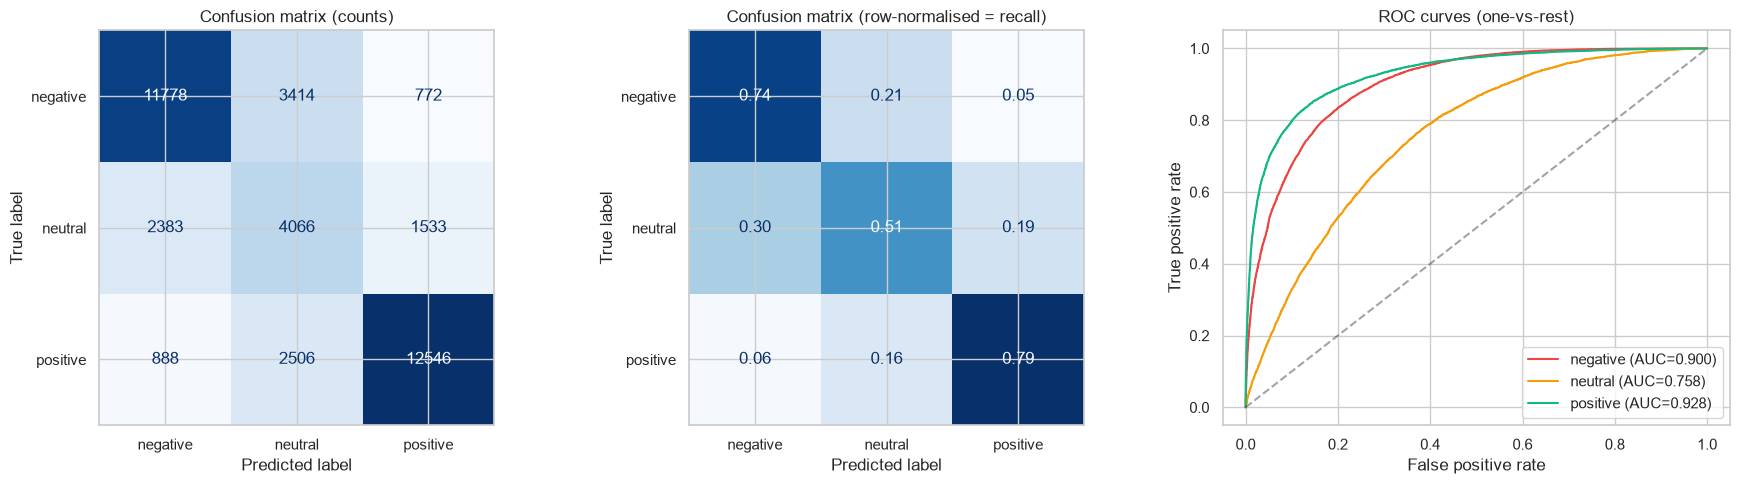

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cm = confusion_matrix(y_test, y_pred, labels=LABELS)
ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(ax=axes[0], cmap="Blues", colorbar=False, values_format="d"); axes[0].set_title("Confusion matrix (counts)")
ConfusionMatrixDisplay(cm / cm.sum(1, keepdims=True), display_labels=LABELS).plot(ax=axes[1], cmap="Blues", colorbar=False, values_format=".2f"); axes[1].set_title("Confusion matrix (row-normalised = recall)")
Yb = label_binarize(y_test, classes=classes)
for i, c in enumerate(classes):
    fpr, tpr, _ = roc_curve(Yb[:, i], proba[:, i]); axes[2].plot(fpr, tpr, color=LABEL_COLORS[c], label=f"{c} (AUC={roc_auc_score(Yb[:, i], proba[:, i]):.3f})")
axes[2].plot([0, 1], [0, 1], "k--", alpha=.4); axes[2].set(title="ROC curves (one-vs-rest)", xlabel="False positive rate", ylabel="True positive rate"); axes[2].legend()
plt.tight_layout(); savefig("evaluation_nb.png"); plt.show()
fig, ax = plt.subplots(figsize=(5, 4));
for i, c in enumerate(classes):
    fpr, tpr, _ = roc_curve(Yb[:, i], proba[:, i]); ax.plot(fpr, tpr, color=LABEL_COLORS[c], label=f"{c} (AUC={roc_auc_score(Yb[:, i], proba[:, i]):.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=.4); ax.set(title="ROC curves", xlabel="FPR", ylabel="TPR"); ax.legend(); plt.tight_layout(); savefig("roc_curves.png"); plt.close()

**Reading the results:** the model is excellent at separating *positive* from *negative* (high AUC and recall). The *neutral* class is the
hardest - a 3-star review mixes praise and criticism, so it lies between the other two classes. This is a property of the labels, not just of the model.

## 9. Error analysis & interpretability

### 9.1 Where does the model go wrong?

In [19]:
err = pd.DataFrame({"review": X_test.values, "actual": y_test.values, "predicted": y_pred, "confidence": proba.max(1)})
err["correct"] = err.actual == err.predicted
print("Share of all errors involving the neutral class:",
      f"{((err.actual == 'neutral') | (err.predicted == 'neutral'))[~err.correct].mean():.1%}")
print("\nAccuracy by review length:")
err["len_bucket"] = pd.cut(err.review.str.split().str.len(), [0, 10, 25, 50, 100, 1000], labels=["<=10", "11-25", "26-50", "51-100", ">100"])
display(err.groupby("len_bucket")["correct"].mean().round(3).to_frame("accuracy"))
pd.crosstab(err.actual, err.predicted, normalize="index").round(3).reindex(index=LABELS, columns=LABELS)

Share of all errors involving the neutral class: 85.6%

Accuracy by review length:


,accuracy
len_bucket,
<=10,0.753
11-25,0.717
26-50,0.707
51-100,0.674
>100,0.646


predicted,negative,neutral,positive
actual,,,
negative,0.738,0.214,0.048
neutral,0.299,0.509,0.192
positive,0.056,0.157,0.787


In [20]:
pd.set_option("display.max_colwidth", 220)
err[~err.correct].sort_values("confidence", ascending=False).head(200).round(3).to_csv(OUT / "error_examples.csv", index=False)
print("CONFIDENT mistakes (model sure, but wrong):")
display(err[~err.correct].sort_values("confidence", ascending=False).head(6)[["review", "actual", "predicted", "confidence"]].round(3))

CONFIDENT mistakes (model sure, but wrong):


,review,actual,predicted,confidence
15145,"All in all, I’m very happy with these. Excellent item, All and all amazing deal for the price! Prompt delivery of a good quality product which is also great value for money. Satisfactory logistics arrived on time Thi...",neutral,positive,0.999
39817,"Horrible received with scratches,I always support SPIGEN COVERS I WILL NEVER AGAIN.very disappointed 😏",neutral,negative,0.996
20081,I wouldn't recommend.,neutral,negative,0.995
20799,This is great little tool. It can almost any dust or dirt from the car. It is small so my kid can handle it very well and to be good helper. Great buy great value. Highly recommend!,neutral,positive,0.995
2681,Very cheap. Do not recommend,neutral,negative,0.992
26584,It not worth your energy. Worst. Junk completely.,neutral,negative,0.984


Many "confident mistakes" are **label noise** - e.g. a glowing review with a 1-star rating (mis-clicked rating) or sarcasm. These are limits of
star-rating-derived labels rather than bugs. Sarcasm and mixed reviews are known open problems for bag-of-words models (addressed in Future Work).

### 9.2 What did the model learn? (most influential words)

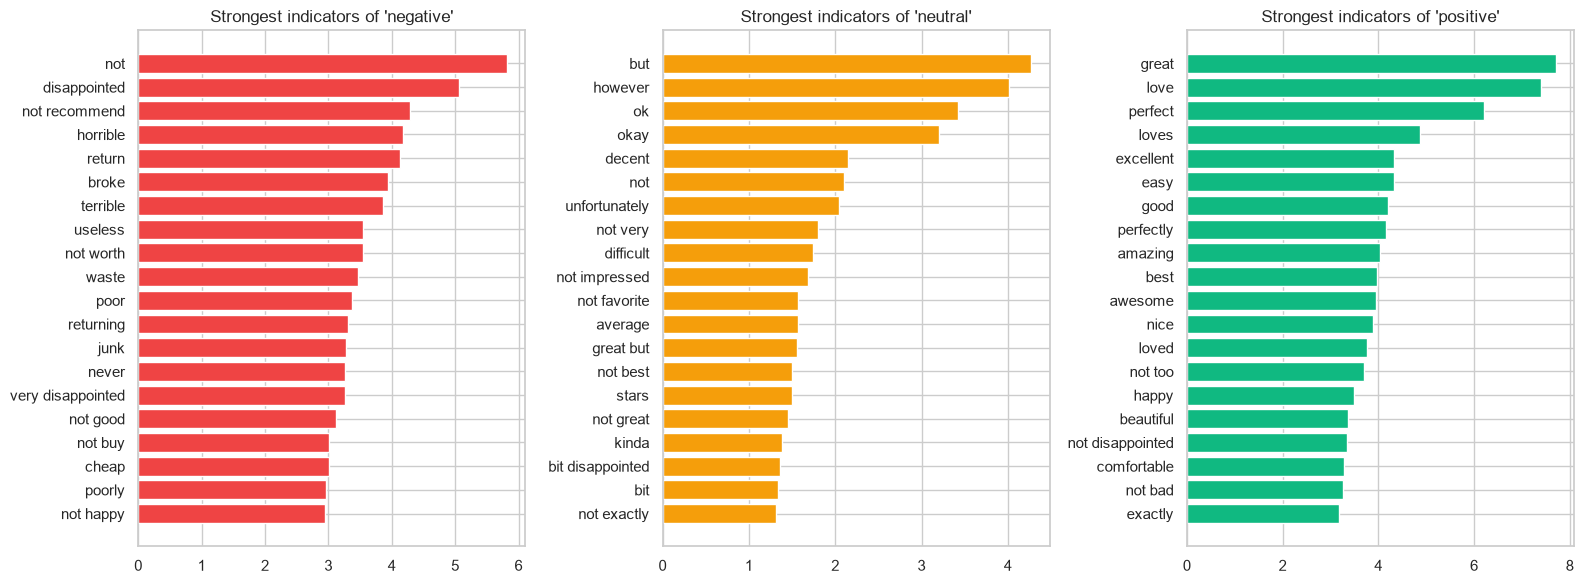

In [21]:
vocab = np.array(vec.get_feature_names_out())
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for i, (c, ax) in enumerate(zip(classes, axes)):
    idx = np.argsort(clf.coef_[i])[::-1][:20][::-1]
    ax.barh(vocab[idx], clf.coef_[i][idx], color=LABEL_COLORS[c]); ax.set_title(f"Strongest indicators of '{c}'")
plt.tight_layout(); savefig("top_words_nb.png"); plt.show()

The learned words are intuitive (*excellent, love, perfect* → positive; *waste, returned, disappointed* → negative; *okay, decent, average* → neutral), which gives confidence that the model learned real sentiment signal rather than artefacts.

### 9.3 Live predictions

In [22]:
def predict(text):
    p = clf.predict_proba(vec.transform([text]))[0]
    return {"review": text, "prediction": classes[p.argmax()], **{c: round(float(x), 3) for c, x in zip(classes, p)}}
tests = ["Absolutely love it, works perfectly and arrived early!",
         "It's okay. Does the job, nothing special.",
         "Broke after two days. Total waste of money, do not buy.",
         "Not bad at all, I am pleasantly surprised.",
         "I can not say I am happy with this."]
pd.DataFrame([predict(t) for t in tests])

,review,prediction,negative,neutral,positive
0,"Absolutely love it, works perfectly and arrived early!",positive,0.002,0.005,0.993
1,"It's okay. Does the job, nothing special.",neutral,0.027,0.903,0.070
2,"Broke after two days. Total waste of money, do not buy.",negative,0.998,0.002,0.000
3,"Not bad at all, I am pleasantly surprised.",positive,0.021,0.133,0.846
4,I can not say I am happy with this.,positive,0.157,0.324,0.519


## 10. The Big Data angle
### 10.1 Scalability study - does more data help, and what does it cost?
We train on growing fractions of the training data and track accuracy and training time.

,train_reviews,macro_f1,accuracy,vectorize_s,fit_s
0,3190,0.6151,0.6561,0.6783,0.2752
1,7977,0.6313,0.6713,2.6499,0.8744
2,15954,0.6434,0.6831,4.2468,1.5630
3,39885,0.6591,0.6963,8.8671,5.0787
4,79770,0.6659,0.7015,17.4268,9.3341
5,159540,0.6757,0.7118,33.6620,37.7877


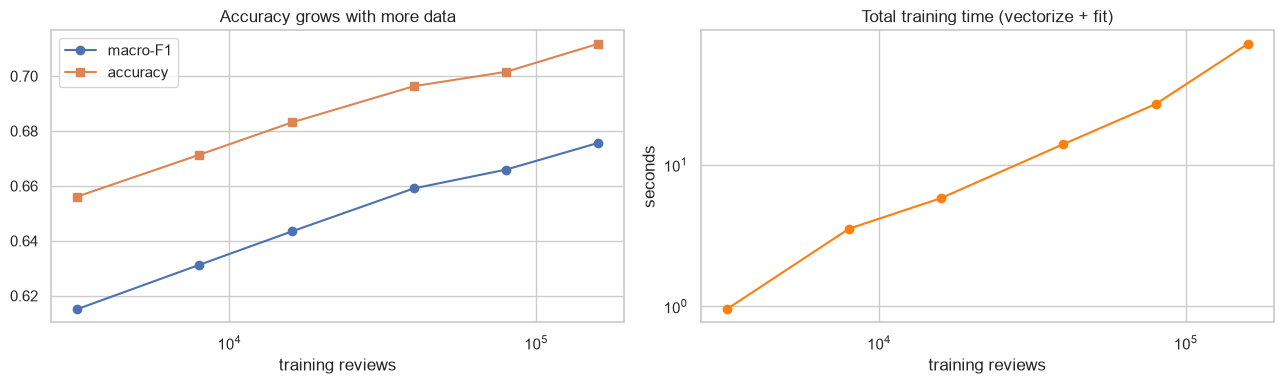

In [23]:
fracs, rows = [0.02, 0.05, 0.1, 0.25, 0.5, 1.0], []
for f in fracs:
    n = int(len(X_fit) * f); idx = X_fit.sample(n, random_state=SEED).index if f < 1 else X_fit.index
    t = time.time(); v = make_vectorizer(); A = v.fit_transform(X_fit.loc[idx]); t_vec = time.time() - t
    t = time.time(); m = LogisticRegression(C=best_C, class_weight="balanced", max_iter=300).fit(A, y_fit.loc[idx]); t_fit = time.time() - t
    s = scores(y_test, m.predict(v.transform(X_test)))
    rows.append({"train_reviews": n, "macro_f1": s["macro_f1"], "accuracy": s["accuracy"], "vectorize_s": t_vec, "fit_s": t_fit})
scal = pd.DataFrame(rows); scal.to_csv(OUT / "scalability.csv", index=False); display(scal.round(4))
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(scal.train_reviews, scal.macro_f1, "o-", label="macro-F1"); ax[0].plot(scal.train_reviews, scal.accuracy, "s-", label="accuracy")
ax[0].set(xscale="log", xlabel="training reviews", title="Accuracy grows with more data"); ax[0].legend()
ax[1].plot(scal.train_reviews, scal.vectorize_s + scal.fit_s, "o-", color="#ff7f0e"); ax[1].set(xscale="log", yscale="log", xlabel="training reviews", ylabel="seconds", title="Total training time (vectorize + fit)")
plt.tight_layout(); savefig("learning_curve.png"); plt.show()

**Takeaway:** performance keeps improving as data grows (the curve has not flattened) - the very reason to analyse reviews at big-data scale - while cost grows close to linearly.

### 10.2 Out-of-core (streaming) training
What if the data **does not fit in memory**? We stream the file in chunks, hash words into a fixed-size feature space with `HashingVectorizer`
(no vocabulary needed in memory) and update an `SGDClassifier` incrementally with `partial_fit`. Memory use depends on the *chunk size*, not the dataset size.

**A classic pitfall:** online learners assume the stream is *randomly ordered*. Our raw file is **sorted by star rating** (1★ first, 5★ last), so a naive pass lets the model "forget" the early classes.
We first run the naive pass to show the problem, then fix it with an out-of-core **shuffle-shard**: each chunk's rows are scattered at random across 8 shard files (one pass, constant memory), and the shards are then streamed.

In [24]:
import json, tempfile
from pathlib import Path
from sklearn.feature_extraction.text import HashingVectorizer
from src.preprocess import stars_to_sentiment

hv = HashingVectorizer(preprocessor=clean_text, stop_words=STOP_WORDS, ngram_range=(1, 2), n_features=2**20, alternate_sign=False, norm="l2")
test_texts = set(X_test)                                  # keep evaluation data out of the stream
CHUNK, K = 20_000, 8
Xte_h = hv.transform(X_test)

def new_sgd():
    # 'balanced' is not allowed with partial_fit (class frequencies unknown up-front): pass n/(3*count) for the known 40/20/40 mix
    return SGDClassifier(loss="log_loss", alpha=1e-5, class_weight={"negative": 0.83, "neutral": 1.67, "positive": 0.83}, random_state=SEED)

def stream(model, sources):
    seen = 0
    for src in sources:
        for chunk in pd.read_json(src, lines=True, chunksize=CHUNK):
            chunk = chunk[~chunk["text"].isin(test_texts)].drop_duplicates("text")
            model.partial_fit(hv.transform(chunk["text"]), (chunk["label"] + 1).map(stars_to_sentiment), classes=LABELS); seen += len(chunk)
    return seen

# (a) naive: stream the file in its stored order (sorted by rating)
t = time.time(); naive = new_sgd(); seen_naive = stream(naive, [RAW_PATH]); t_naive = time.time() - t
s_naive = scores(y_test, naive.predict(Xte_h))
print(f"NAIVE (sorted file)   : streamed {seen_naive:,} reviews in {t_naive:.0f}s -> accuracy={s_naive['accuracy']:.4f}  macro-F1={s_naive['macro_f1']:.4f}   <- collapses to the last classes seen")

NAIVE (sorted file)   : streamed 159,796 reviews in 33s -> accuracy=0.3996  macro-F1=0.1904   <- collapses to the last classes seen


In [25]:
# (b) fix: out-of-core shuffle-shard (one pass, one chunk in memory at a time), then stream the shards
t = time.time()
shard_dir, rng = Path(tempfile.mkdtemp()), np.random.default_rng(SEED)
files = [open(shard_dir / f"shard_{i}.jsonl", "w", encoding="utf-8") for i in range(K)]
for chunk in pd.read_json(RAW_PATH, lines=True, chunksize=CHUNK):
    chunk = chunk[~chunk["text"].isin(test_texts)]
    part = rng.integers(0, K, len(chunk))
    for k in range(K):
        out = chunk[part == k].to_json(orient="records", lines=True)
        files[k].write(out if out.endswith("\n") else out + "\n")
for f in files: f.close()
sgd = new_sgd(); seen = stream(sgd, sorted(shard_dir.glob("shard_*.jsonl"))); t_stream = time.time() - t
s = scores(y_test, sgd.predict(Xte_h))
print(f"SHUFFLE-SHARD + stream: streamed {seen:,} reviews in chunks of {CHUNK:,} ({t_stream:.0f}s) -> accuracy={s['accuracy']:.4f}  macro-F1={s['macro_f1']:.4f}")
print(f"In-memory Logistic Regression for comparison: accuracy={res['accuracy']:.4f}  macro-F1={res['macro_f1']:.4f}")
(OUT / "streaming.json").write_text(json.dumps({"reviews_streamed": seen, "chunk_size": CHUNK, "shards": K, "seconds": t_stream,
    "stream_accuracy": s["accuracy"], "stream_macro_f1": s["macro_f1"], "naive_accuracy": s_naive["accuracy"], "naive_macro_f1": s_naive["macro_f1"],
    "inmem_accuracy": res["accuracy"], "inmem_macro_f1": res["macro_f1"]}, indent=2))

SHUFFLE-SHARD + stream: streamed 159,885 reviews in chunks of 20,000 (47s) -> accuracy=0.7142  macro-F1=0.6538
In-memory Logistic Regression for comparison: accuracy=0.7118  macro-F1=0.6757


345

**Takeaways.** (1) The raw data are ordered by label, and ignoring that makes an online learner collapse to ~40 % accuracy (it predicts only the class it saw last).
(2) After an out-of-core shuffle, a *single pass* with constant memory reaches accuracy close to the in-memory model, so the same approach scales to millions of reviews (or to Spark/Dask).

## 11. Business insights
Beyond classification, what do customers complain about? We tag reviews with common **themes** via keyword matching and measure the share of negative reviews per theme.

,theme,mentions,pct_negative,pct_positive
5,Customer service,18029,0.697,0.141
1,Product quality,30755,0.515,0.286
0,Shipping / delivery,19856,0.511,0.307
6,Durability,16621,0.493,0.302
4,Battery / power,8841,0.479,0.349
2,Price / value,22844,0.409,0.426
3,Size / fit,38676,0.345,0.416
7,Ease of use,19181,0.267,0.554


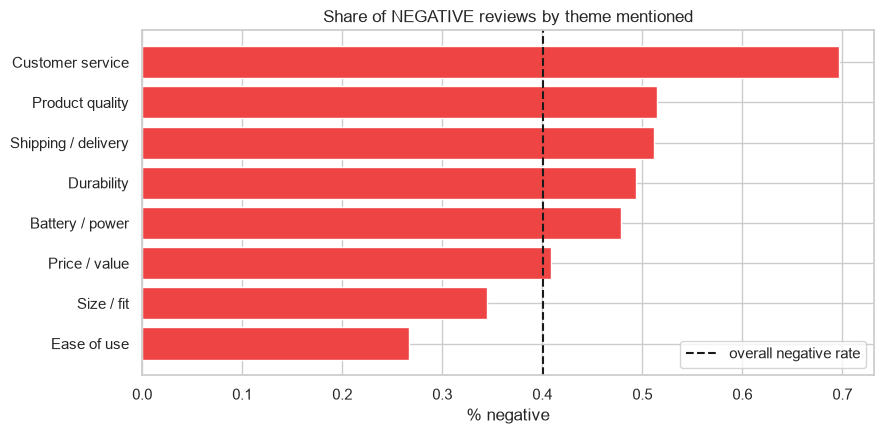

In [26]:
themes = {
    "Shipping / delivery": r"ship|deliver|arriv|package|packag|late",
    "Product quality":     r"quality|cheap|flimsy|broke|broken|defect|poor",
    "Price / value":       r"price|money|worth|expensive|overpriced|value",
    "Size / fit":          r"size|fit|small|large|tight|loose",
    "Battery / power":     r"battery|charge|charger|power",
    "Customer service":    r"customer service|refund|return|seller|support|warranty",
    "Durability":          r"stopped working|last|durab|fell apart|after a week|after a month",
    "Ease of use":         r"easy|simple|install|setup|set up|instructions|difficult",
}
rows = []
for theme, pat in themes.items():
    mask = df["review"].str.contains(pat, case=False, regex=True)
    sub_ = df[mask]
    rows.append({"theme": theme, "mentions": len(sub_), "pct_negative": (sub_.sentiment == "negative").mean(), "pct_positive": (sub_.sentiment == "positive").mean()})
theme_df = pd.DataFrame(rows).sort_values("pct_negative", ascending=False); theme_df.to_csv(OUT / "themes.csv", index=False)
display(theme_df.round(3))
fig, ax = plt.subplots(figsize=(9, 4.5))
t_ = theme_df.sort_values("pct_negative")
ax.barh(t_.theme, t_.pct_negative, color=LABEL_COLORS["negative"]); ax.axvline((df.sentiment == "negative").mean(), color="k", ls="--", label="overall negative rate")
ax.set(title="Share of NEGATIVE reviews by theme mentioned", xlabel="% negative"); ax.legend(); plt.tight_layout(); savefig("eda_theme_negative_rate.png"); plt.show()

**Business recommendation:** themes whose negative rate sits well above the dashed baseline (typically *customer service / refunds, durability and product quality*)
are the highest-priority areas for the business, because mentioning them strongly predicts an unhappy customer.

## 12. Conclusions
* A **TF-IDF (1-2 gram) + Logistic Regression** pipeline classifies reviews into 3 sentiment classes with strong accuracy and macro-F1 on a held-out test set (see Section 8).
* Design choices were **validated, not assumed**: bigrams and keeping negations measurably help (ablation), classes are balanced via class weights, and the test set was used once.
* Errors concentrate on the **neutral** class, whose labels are inherently ambiguous; confident errors are often label noise or sarcasm.
* The solution is **scalable**: sparse matrices, linear models, near-linear training time and an out-of-core streaming variant.
* Business insight: complaint themes with the highest negative rates highlight where to improve.
* Deployed as an interactive **Streamlit app** (`streamlit run app.py`) with single-review prediction + explanations, batch CSV analysis and a performance dashboard.

### Other ideas we tested (validation set, macro-F1)
| Idea | Result vs. chosen model (0.667) |
|---|---|
| Train on 5 star labels, merge probabilities into 3 classes | 0.638 (better accuracy 72.0 %, worse neutral recall) |
| Average of 3-class and merged 5-class models | 0.660 |
| Tune a neutral-class decision threshold | 0.668 (+0.001, negligible) |
| Add character 3-5-gram TF-IDF features | 0.674 (+0.007, but 2x the features and slower) |

None gave a meaningful gain, which suggests we are close to the ceiling of bag-of-words models on these noisy labels; the next real jump would need a transformer.

### Limitations & future work
* Star ratings are noisy proxies for sentiment; human-labelled data would be cleaner.
* Bag-of-words ignores word order and sarcasm → try transformer models (DistilBERT / RoBERTa) or sentence embeddings.
* Add aspect-based sentiment (price vs. quality vs. delivery) and multilingual support.
* Scale beyond one machine with Spark MLlib or Dask.